In [1]:
import numpy as np 
import pandas as pd

In [7]:
df = pd.read_csv("compressed_data.csv")

C:\Users\kuber\AppData\Local\Temp\ipykernel_18216\1184112827.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("compressed_data.csv")


In [11]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [15]:
df.isnull().sum()


id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [57]:
# Fixing the datatype of colunm last review 
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

In [64]:
# Fill the null values of reviews per month and last review with 0 and minimum date respectively
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace = True)

In [69]:
df.dropna(subset = ['NAME', 'host name'], inplace = True)


In [81]:
df.isnull().sum()

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       403
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   314
calculated host listings count       318
availability 365                     420
house_rules     

In [ ]:
# Drop the last 2 column name is house_rules and licence
df.drop(columns = ['licence', 'house_rules'], errors = 'coerce')

In [86]:
# Remove the $ sign from price and service column (Replace)
df['price'] = df['price'].replace('[/$,]', "", regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[/$,]', "", regex=True).astype(float)

In [90]:
# Remove Duplicates 
df.drop_duplicates(inplace=True)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  object        
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country code                    101288 non-null  object      

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns 

# Visiulaization

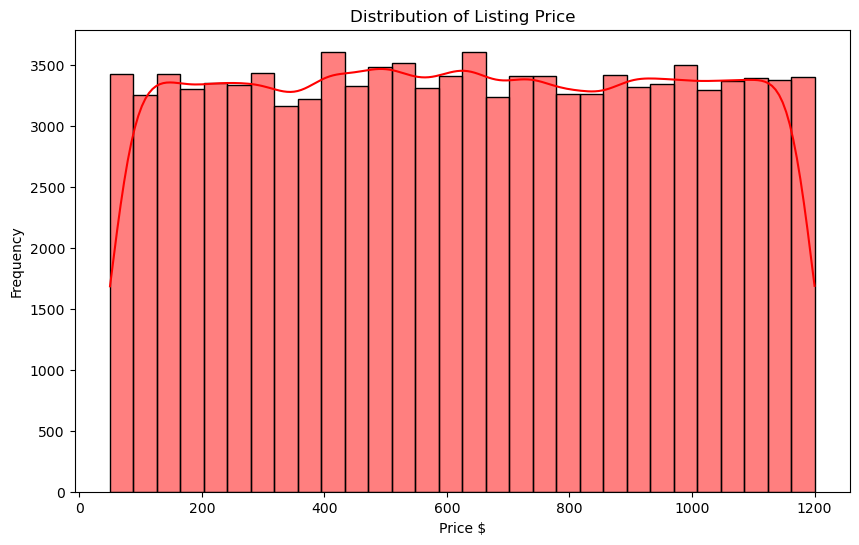

In [112]:
plt.figure(figsize = (10,6))
sns.histplot(df['price'], bins=30, kde = True, color='red', edgecolor='black')
plt.title('Distribution of Listing Price')
plt.xlabel('Price $')
plt.ylabel('Frequency')
plt.show()

In [114]:
df['room type']

0            Private room
1         Entire home/apt
2            Private room
4         Entire home/apt
5         Entire home/apt
               ...       
102053       Private room
102054       Private room
102055    Entire home/apt
102056       Private room
102057    Entire home/apt
Name: room type, Length: 101410, dtype: object

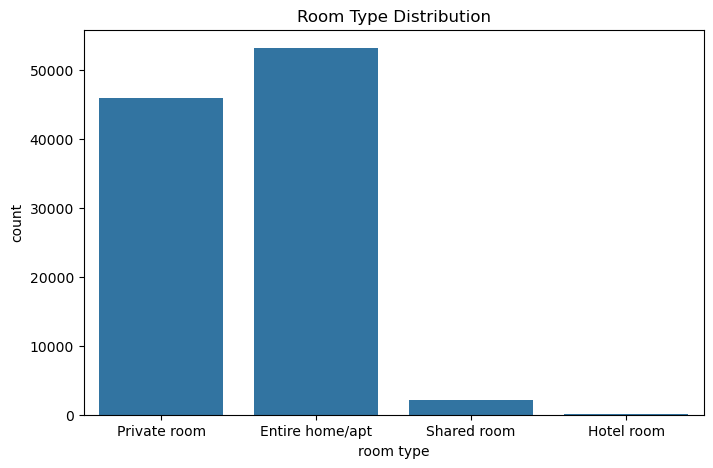

In [122]:
# Different type of Room Distribution
plt.figure(figsize = (8,5))
sns.countplot(x = 'room type', data = df)
plt.title("Room Type Distribution")
plt.show()

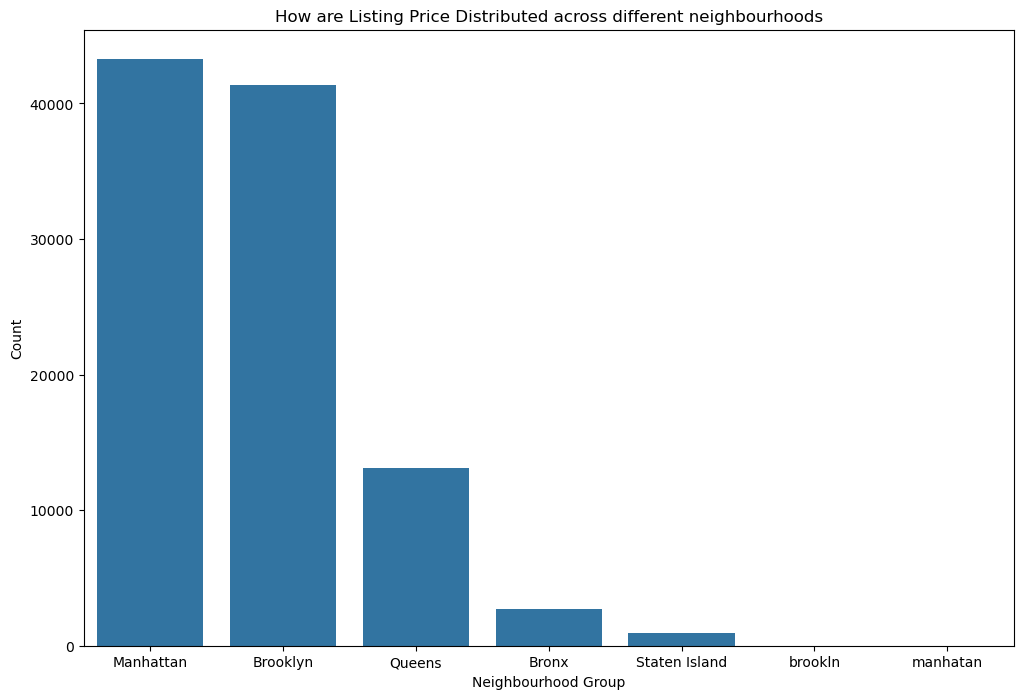

In [138]:
plt.figure(figsize = (12,8))
sns.countplot(x = "neighbourhood group", data = df, order = df['neighbourhood group'].value_counts().index)
plt.title('How are Listing Price Distributed across different neighbourhoods')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


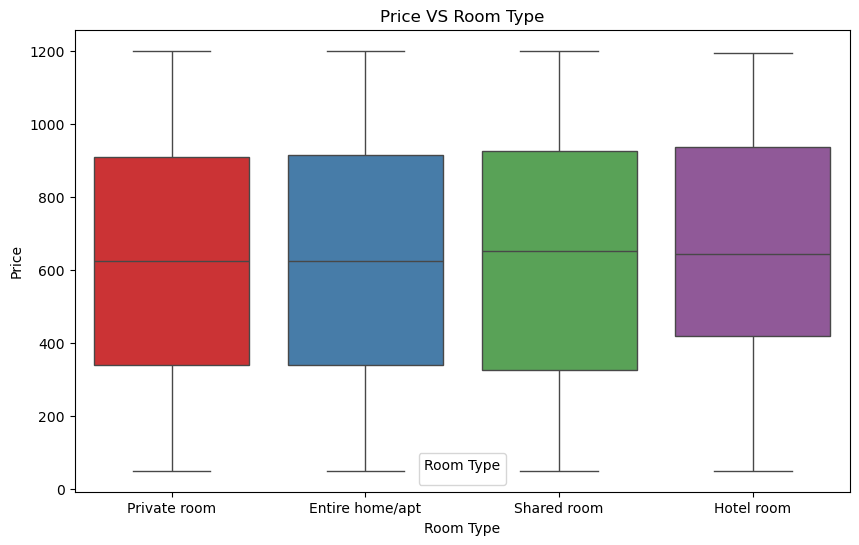

In [142]:
plt.figure(figsize=(10,6))
sns.boxplot(x='room type', y='price', hue = 'room type', data = df, palette = 'Set1')
plt.title('Price VS Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.legend(title='Room Type')
plt.show()